# Setup
This section loads libraries and the dataset.

In [67]:
# Load libraries

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap

In [68]:
# Load dataset
df = pd.read_csv("../data/Mall_Customers.xls")

# Check if dataset is loaded
print(f"Dataframe shape: {df.shape}")
print(f"Dataframe columns: {df.columns.to_list()}")
df.head()

Dataframe shape: (200, 5)
Dataframe columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [69]:
# Check data types
print("Dataset information: ")
print(df.info())

# Check for missing values
print("\nMissing values: ")
print(df.isnull().sum())

# Statistics
print("\nDescriptive statistics: ")
print(df.describe())

Dataset information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing values: 
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Descriptive statistics: 
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007       

In [70]:
# Convert Gender into numerical
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False


# Preprocessing
This section prepares the dataset for analysis by cleaning the data of missing values and scaling data to equalize distances between clusters.

In [71]:
# Define feature columns (Customer information)
features = ["Gender_Male", "Age", "Annual Income (k$)", "Spending Score (1-100)"]

# Extract features for analysis
df_features = df[features]

# Check if features are extracted
print(f"Features shape: {df_features.shape}")
print(f"Features columns: {df_features.columns.to_list()}")
df_features.head()

Features shape: (200, 4)
Features columns: ['Gender_Male', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,Gender_Male,Age,Annual Income (k$),Spending Score (1-100)
0,True,19,15,39
1,True,21,15,81
2,False,20,16,6
3,False,23,16,77
4,False,31,17,40


In [73]:
# Scale features with StandardScaler
features_to_be_scaled = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features[features_to_be_scaled])
df_scaled = pd.DataFrame(df_scaled, columns=features_to_be_scaled)
df_scaled["Gender_Male"] = df_features["Gender_Male"]

# Check if features are scaled
print(f"Scaled features shape: {df_scaled.shape}")
print(f"Scaled features columns: {df_scaled.columns.to_list()}")
df_scaled.head()

Scaled features shape: (200, 4)
Scaled features columns: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']


,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,True
1,-1.281035,-1.738999,1.195704,True
2,-1.352802,-1.700830,-1.715913,False
3,-1.137502,-1.700830,1.040418,False
4,-0.563369,-1.662660,-0.395980,False


# Clustering Analysis
This section seperates the dataset into multiple cluster and analyzes customer behaviour based off of our clusters.

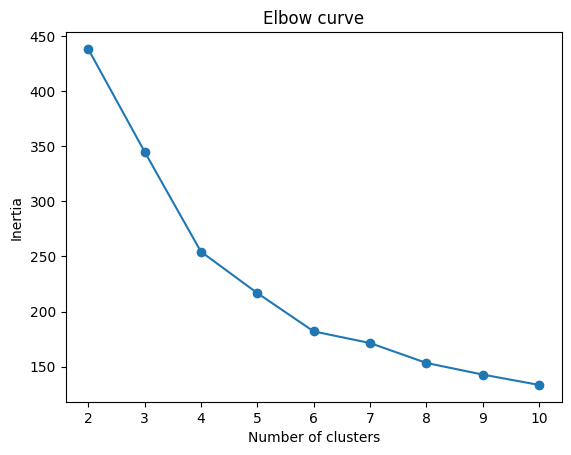

In [74]:
# Implement elbow method
inertia = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow curve')
plt.show()

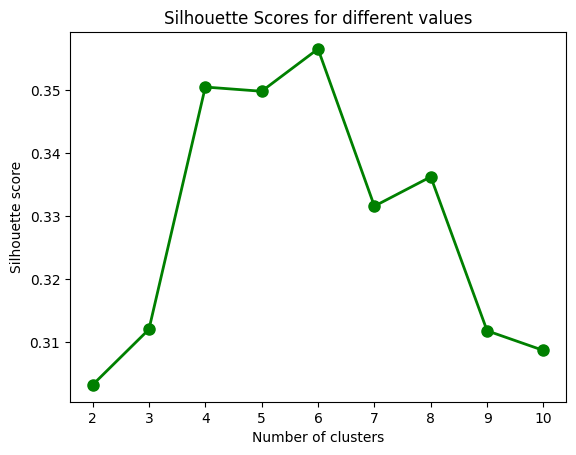

In [75]:
# Calculate silhouette scores for K=2 to K=10
silhouette_scores = []

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(df_scaled)
  labels = kmeans.labels_
  silhouette_scores.append(silhouette_score(df_scaled, labels))

# Plot silhouette scores
plt.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette Scores for different values')
plt.show()

We decided to pick K=6 because the elbow curve shows a significant change in interia and the highest silhouette score.

In [76]:
# Fit K-Means model
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(df_scaled)
cluster_labels = kmeans.labels_

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts())


Cluster distribution:
Cluster
0    45
1    39
5    38
3    34
4    23
2    21
Name: count, dtype: int64


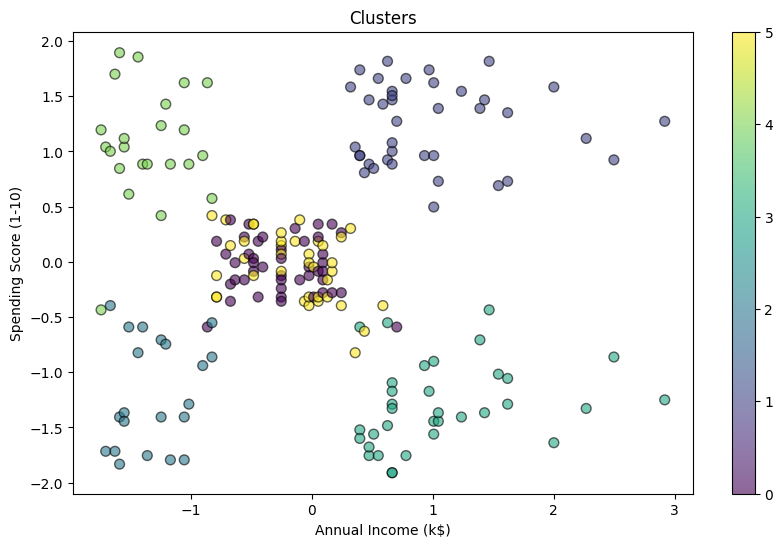

In [77]:
# Visualize clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_scaled['Annual Income (k$)'],
                      df_scaled['Spending Score (1-100)'], c=cluster_labels,
                      cmap='viridis', alpha=0.6, edgecolors='k', s=50)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-10)')
plt.title('Clusters')
plt.colorbar(scatter)
plt.show()

In [90]:
# Analyze mean customer information for each cluster
cluster_spending = df.groupby('Cluster')[features_to_be_scaled].mean().reset_index()

print(f"\nMean spending score for each cluster:")
print(cluster_spending)

# Analyze gender distribution for each cluster
cluster_gender = df.groupby('Cluster')['Gender_Male'].value_counts(normalize=True).unstack().reset_index()

print(f"\nGender distribution for each cluster:")
print(cluster_gender)


Mean spending score for each cluster:
   Cluster        Age  Annual Income (k$)  Spending Score (1-100)
0        0  56.333333           54.266667               49.066667
1        1  32.692308           86.538462               82.128205
2        2  45.523810           26.285714               19.380952
3        3  41.264706           88.500000               16.764706
4        4  25.000000           25.260870               77.608696
5        5  27.000000           56.657895               49.131579

Gender distribution for each cluster:
Gender_Male  Cluster     False      True
0                  0  0.577778  0.422222
1                  1  0.538462  0.461538
2                  2  0.619048  0.380952
3                  3  0.411765  0.588235
4                  4  0.565217  0.434783
5                  5  0.657895  0.342105
['Cluster', False, True]


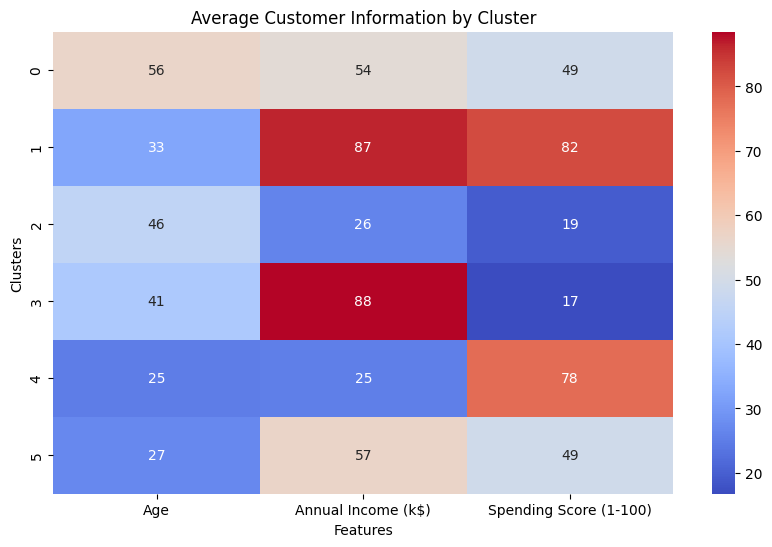

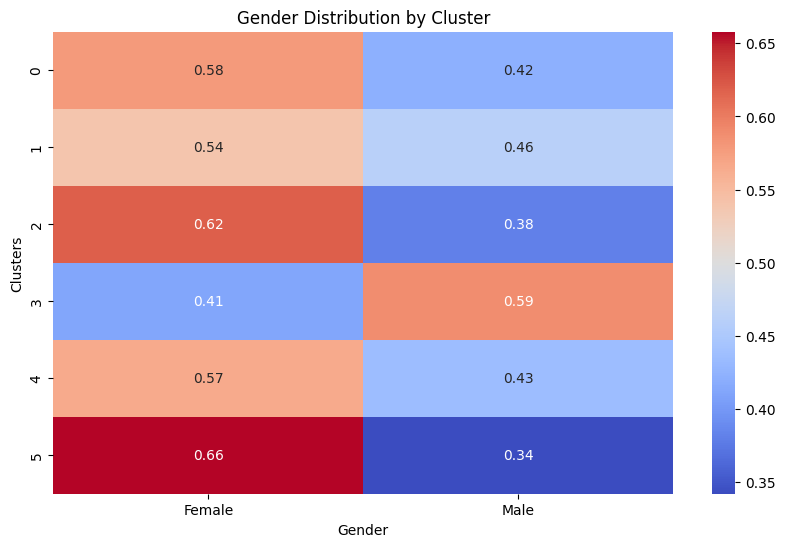

In [102]:
# Create heatmap for cluster means
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_spending[features_to_be_scaled], annot=True, cmap='coolwarm')
plt.xlabel('Features')
plt.ylabel('Clusters')
plt.title('Average Customer Information by Cluster')
plt.show()

# Create heatmap for gender distribution
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_gender.iloc[:, 1:], annot=True, cmap='coolwarm')
plt.xlabel('Gender')
plt.ylabel('Clusters')
plt.title('Gender Distribution by Cluster')
plt.xticks([0.5, 1.5], ['Female', 'Male'])
plt.show()

# Cluster Characteristics

Cluster 0: Slightly Female (58%), middle age (56 average age), middle income (54k annual income), medium spender (49 score)

Cluster 1: Slightly Female (54%), middle age (33 average age), high income (87k annual income), high spender (82 score)

Cluster 2: Mostly Female (62%), middle age (46 average age), low income (19k annual income), very low spender (19 score)

Cluster 3: Slightly Male (59%), middle age (41 average age), high income (88k annual income), very low spender (17 score)

Cluster 4: Slightly Female (57%), young (25 average age), low income (17k annual income), high spender (79 score)

Cluster 5: Mostly Female (66%), young (27 average age), middle income (57k annual income), medium spender (49 score)

# Cluster Names

Cluster 0: We named this cluster **Moderate Shopper** because the means do not suggest that this demographic has much more potential to spend more than the listed characteristics.

Cluster 1: We named this cluster **Trendy Customer** because these customers statistics suggest that this group spends based on trends because of their income, age, and spending scores.

Cluster 2: We named this cluster **Budget Female Spender** because of their low income correlating with their low spending score.

Cluster 3: We named this cluster **Stingy Buyers** because their spending score of 17 has the potential to be higher because of their annual income of $88k per year.

Cluster 4: We named this cluster **Young Consumer** because of their young age, low income, but high spending score.

Cluster 5: We named this cluster **Young Female Shopper** because of their young age and uneven distribution leaning towards women.